# Regular Season Game Prediction with Wide & Deep Neural Network
This notebook predicts regular season college basketball games using running statistics to avoid data leakage.

## Key Features:
- Running statistics calculated game-by-game (no future data leakage)
- Excludes games where team stats contain zeros
- Home court advantage
- Adjusted offensive/defensive efficiency (AdjO/AdjD)
- Opponent strength adjustment
- Consistency metrics
- Form rating (recent performance)

In [1]:
import kagglehub
kagglehub.login()

In [2]:
march_machine_learning_mania_2026_path = kagglehub.competition_download('march-machine-learning-mania-2026')
print(march_machine_learning_mania_2026_path)
print('Data source import complete.')

C:\Users\sathv\.cache\kagglehub\competitions\march-machine-learning-mania-2026
Data source import complete.


In [3]:
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from scipy import stats
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt
import copy
import os
from pathlib import Path
from collections import defaultdict
import sportsdataverse.mbb as mbb

## Load Data

In [4]:
# Load reference data
mens_teams = pd.read_csv(os.path.join(march_machine_learning_mania_2026_path, 'MTeams.csv'))
mens_teams_spelling = pd.read_csv(os.path.join(march_machine_learning_mania_2026_path, 'MTeamSpellings.csv'))

print(f"Teams: {len(mens_teams)}")
print(f"Team spellings: {len(mens_teams_spelling)}")
mens_teams.head()

Teams: 381
Team spellings: 1178


,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014,2026
1,1102,Air Force,1985,2026
2,1103,Akron,1985,2026
3,1104,Alabama,1985,2026
4,1105,Alabama A&M,2000,2026


In [ ]:
from datetime import date
def _filter_by_date(df, start_date, end_date):
    if df is None or len(df) == 0:
        return df
    date_col = next((col for col in df.columns if 'date' in col.lower()), None)
    if date_col is None:
        print('Warning: No date column found. Returning unfiltered data.')
        return df
    filtered = df.copy()
    # Normalize to UTC to avoid tz-naive vs tz-aware comparisons.
    filtered[date_col] = pd.to_datetime(filtered[date_col], errors='coerce', utc=True)
    start_date = pd.to_datetime(start_date, utc=True)
    end_date = pd.to_datetime(end_date, utc=True)
    return filtered[(filtered[date_col] >= start_date) & (filtered[date_col] <= end_date)]

def _load_by_season(loader, seasons):
    frames = []
    for season in seasons:
        try:
            frames.append(loader(seasons=[season], return_as_pandas=True))
        except Exception as exc:
            print(f"Warning: failed to load season {season}: {exc}")
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True, sort=False)

def import_recent_matchups(from_date, to_date=None):
    end_date = to_date or pd.Timestamp.today().strftime('%Y-%m-%d')
    start_date = pd.to_datetime(from_date, utc=True)
    end_date = pd.to_datetime(end_date, utc=True)
    seasons = list(range(start_date.year, end_date.year + 1))
    try:
        schedule = _load_by_season(mbb.load_mbb_schedule, seasons)
        player_box = _load_by_season(mbb.load_mbb_player_boxscore, seasons)
        team_box = _load_by_season(mbb.load_mbb_team_boxscore, seasons)
        schedule = _filter_by_date(schedule, start_date, end_date)
        player_box = _filter_by_date(player_box, start_date, end_date)
        team_box = _filter_by_date(team_box, start_date, end_date)
        print(f"Successfully imported range from {start_date.date()} to {end_date.date()}.")
        return schedule, player_box, team_box
    except Exception as exc:
        print(f"Fatal Error: {exc}")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

last_date_fetched = '03-02-2026' # Adjust to whatever start date you want for fetching matchups
schedule, alltime_matchups, team_box = import_recent_matchups(last_date_fetched, date.today().strftime('%Y-%m-%d'))

team_box_path = 'Alltime_Matchups_Team_Box_Score.csv'
if os.path.exists(team_box_path):
    existing_team_box = pd.read_csv(team_box_path)
    combined_team_box = pd.concat([existing_team_box, team_box], ignore_index=True, sort=False)
else:
    combined_team_box = team_box.copy()

combined_team_box = combined_team_box.drop_duplicates().reset_index(drop=True)
combined_team_box.to_csv(team_box_path, index=False)

100%|██████████| 1/1 [00:00<00:00,  3.33it/s]


Successfully imported range from 2026-03-02 to 2026-03-03.


In [6]:
team_box_usecols = [
    "game_id", "season", "game_date", "season_type",
    "team_name", "team_display_name", "team_abbreviation", "team_slug", "team_uid", "team_location",
    "team_winner", "team_home_away", "team_score",
    "field_goals_made", "field_goals_attempted",
    "three_point_field_goals_made", "three_point_field_goals_attempted",
    "free_throws_made", "free_throws_attempted",
    "offensive_rebounds", "defensive_rebounds", "assists", "turnovers", "steals", "blocks", "fouls",
    "total_rebounds"
]

team_box_score = pd.read_csv(
    "Alltime_Matchups_Team_Box_Score.csv",
    engine="pyarrow",
    usecols=team_box_usecols,
)
team_box_score.head()

,game_id,season,game_date,season_type,team_name,team_display_name,team_abbreviation,team_slug,team_uid,team_location,...,free_throws_made,free_throws_attempted,offensive_rebounds,defensive_rebounds,assists,turnovers,steals,blocks,fouls,total_rebounds
0,230682250,2003,2003-03-10 00:00:00+00:00,2,Gaels,Saint Mary's Gaels,SMC,saint-marys-gaels,s:40~l:41~t:2608,Saint Mary's,...,16,23,10,20,7,18,3,3,21,34
1,230682250,2003,2003-03-10 00:00:00+00:00,2,Bulldogs,Gonzaga Bulldogs,GONZ,gonzaga-bulldogs,s:40~l:41~t:2250,Gonzaga,...,21,27,12,23,9,8,10,3,20,41
2,233432507,2004,2003-12-09 00:00:00+00:00,2,Fighting Illini,Illinois Fighting Illini,ILL,illinois-fighting-illini,s:40~l:41~t:356,Illinois,...,3,8,16,20,17,22,6,2,20,38
3,233432507,2004,2003-12-09 00:00:00+00:00,2,Friars,Providence Friars,PROV,providence-friars,s:40~l:41~t:2507,Providence,...,11,19,19,20,14,14,10,7,12,44
4,233300013,2004,2003-11-26 00:00:00+00:00,2,Buffaloes,Colorado Buffaloes,COLO,colorado-buffaloes,s:40~l:41~t:38,Colorado,...,16,23,12,33,9,14,9,6,17,48


In [7]:
def convert_team_boxscore_to_kaggle(team_box_df, team_spellings_df):
    df = team_box_df.copy()
    
    # ... [Keep Section 1 exactly as it was] ...
    if team_spellings_df is None or team_spellings_df.empty:
        raise ValueError("Team spellings dataframe is empty.")
        
    spellings = team_spellings_df.copy()
    spellings['clean_spelling'] = (spellings['TeamNameSpelling']
                                   .astype(str).str.lower()
                                   .str.replace(r'[.,\'-]', '', regex=True)
                                   .str.strip())
    spelling_map = dict(zip(spellings['clean_spelling'], spellings['TeamID']))

    def clean_name(name):
        if pd.isna(name):
            return ""
        s = str(name).lower().replace('&', 'and')
        for char in [".", ",", "'", "-"]:
            s = s.replace(char, "")
        return " ".join(s.split())

    # ---------------------------------------------------------
    # 2. Map the Team IDs (Waterfall Approach FIX)
    # ---------------------------------------------------------
    df['clean_loc'] = df['team_location'].apply(clean_name)
    df['clean_display'] = df['team_display_name'].apply(clean_name)
    
    # First attempt: Direct mapping
    manual_overrides = {
        'St. Thomas-Minnesota Tommies': 1472, 
        'Texas A&M-Corpus Christi Islanders': 1394, 
        'Florida A&M Rattlers': 1197, 
        'Alabama A&M Bulldogs': 1105, 
        'Prairie View A&M Panthers': 1341,
        'East Texas A&M Lions': 1477,          # Kaggle: TX A&M Commerce
        'UT Rio Grande Valley Vaqueros': 1410, # Kaggle: UTRGV
        'San José State Spartans': 1363,       # Kaggle: San Jose St (Accent mark breaks the regex)
        'Texas A&M Aggies': 1401,              # Kaggle: Texas A&M
        'Miami Hurricanes': 1274,              # Kaggle: Miami FL
        'UAlbany Great Danes': 1107,           # Kaggle: Albany NY
        'William & Mary Tribe': 1456,          # Kaggle: William & Mary
        'North Carolina A&T Aggies': 1299,     # Kaggle: NC A&T
        'Queens University Royals': 1474,      # Kaggle: Queens NC
        'Saint Francis Red Flash': 1384,       # Kaggle: St Francis PA
        'App State Mountaineers': 1111,        # Kaggle: Appalachian St
        'UL Monroe Warhawks': 1419             # Kaggle: ULM
    }
    # Map raw names to IDs. Will return NaN for teams not in this dict.
    df['Kaggle_TeamID'] = df['team_display_name'].map(manual_overrides).astype('Int64')
    
    # ATTEMPT 1: Direct mapping
    mask = df['Kaggle_TeamID'].isna()
    df.loc[mask, 'Kaggle_TeamID'] = df.loc[mask, 'clean_loc'].map(spelling_map)
    
    # ATTEMPT 2: Full display name
    mask = df['Kaggle_TeamID'].isna()
    df.loc[mask, 'Kaggle_TeamID'] = df.loc[mask, 'clean_display'].map(spelling_map)
    
    # ATTEMPT 3: Stripped Mascot
    mask = df['Kaggle_TeamID'].isna()
    df.loc[mask, 'Kaggle_TeamID'] = df.loc[mask, 'clean_display'].apply(
    lambda x: spelling_map.get(" ".join(x.split()[:-1]), np.nan)
    )

    # Print a warning if any teams slipped through
    missing_teams = df[df['Kaggle_TeamID'].isna()]['team_display_name'].unique()
    if len(missing_teams) > 0:
        print(f"⚠️ Warning: Could not map IDs for {len(missing_teams)} teams: {missing_teams}")

    # ... [Keep the rest of the function exactly as it was] ...
    
    # 3. Calculate DayNum (season-by-season)
    df['game_date'] = pd.to_datetime(df['game_date']).dt.tz_localize(None) 
    season_start = df.groupby('season')['game_date'].transform('min')
    df['DayNum'] = (df['game_date'] - season_start).dt.days

    # 4. Split Winners and Losers
    winners = df[df['team_winner'] == True].copy()
    losers = df[df['team_winner'] == False].copy()

    if winners.empty or losers.empty:
        raise ValueError("Could not separate winners and losers. Check 'team_winner' column.")

    # 5. Merge Matchups
    matchup = winners.merge(
    losers, 
    on=['game_id', 'season', 'DayNum'], 
    suffixes=('_W', '_L')
    )
    # 6. Format the Final Output
    output = pd.DataFrame()
    output['Season'] = matchup['season']
    output['DayNum'] = matchup['DayNum']
    
    # Safely cast to nullable integer types (Int64)
    output['WTeamID'] = matchup['Kaggle_TeamID_W'].astype('Int64')
    output['WScore'] = matchup['team_score_W']
    output['LTeamID'] = matchup['Kaggle_TeamID_L'].astype('Int64')
    output['LScore'] = matchup['team_score_L']
    
    output['WLoc'] = matchup['team_home_away_W'].str.lower().map({
        'home': 'H',
        'away': 'A'
    }).fillna('N')
    
    output['NumOT'] = 0 
    
    stat_cols = {
        'FGM': 'field_goals_made',
        'FGA': 'field_goals_attempted',
        'FGM3': 'three_point_field_goals_made',
        'FGA3': 'three_point_field_goals_attempted', 
        'FTM': 'free_throws_made',
        'FTA': 'free_throws_attempted',
        'OR': 'offensive_rebounds',
        'DR': 'defensive_rebounds',
        'Ast': 'assists',
        'TO': 'turnovers',
        'Stl': 'steals',
        'Blk': 'blocks',
        'PF': 'fouls'
    }

    for k_stat, raw_stat in stat_cols.items():
        output[f'W{k_stat}'] = matchup[f'{raw_stat}_W']
        output[f'L{k_stat}'] = matchup[f'{raw_stat}_L']

    final_cols = [
        'Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc',
        'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR',
        'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3',
        'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF'
    ]
    
    extra_map = {
        'GameID': 'game_id',
        'GameDate': 'game_date_W',
        'WTeamDisplayName': 'team_display_name_W',
        'LTeamDisplayName': 'team_display_name_L',
    }
    
    extra_cols = []
    for out_col, src_col in extra_map.items():
        if src_col in matchup.columns:
            if out_col == 'GameDate':
                output[out_col] = pd.to_datetime(matchup[src_col], errors='coerce')
            else:
                output[out_col] = matchup[src_col]
        else:
            output[out_col] = pd.NA
        extra_cols.append(out_col)
    
    return output[final_cols + extra_cols]

alltime_matchups = convert_team_boxscore_to_kaggle(team_box_score, mens_teams_spelling).reset_index(drop=True)
alltime_matchups['WTeamID'].dropna().unique()
alltime_matchups['LTeamID'].dropna().unique()
alltime_matchups.to_csv('Alltime_Matchups_Converted.csv', index=False)

⚠️ Warning: Could not map IDs for 1288 teams: <ArrowStringArray>
[                    'Northern Michigan Wildcats',
                  'Centenary Louisiana Gentlemen',
                        'Colorado College Tigers',
                               'Reinhardt Eagles',
    'Colorado at Colorado Springs Mountain Lions',
                       'St. Edward's Hilltoppers',
                    'Texas-Permian Basin Falcons',
                                'Rockhurst Hawks',
                                'Haverford Fords',
                 'Mont St Billings Yellowjackets',
 ...
           'Health Sciences & Pharmacy Eutectics',
                               'Allegheny Gators',
                  'Converse University Valkyries',
                               'Caldwell Cougars',
                        'St. Joseph's (NY) Bears',
                                'Caltech CALTECH',
                          'Northern State Wolves',
          'Oklahoma Christian OKLAHOMA CHRISTIAN',
            

In [8]:
# Use only scraped matchup data (Kaggle-format columns + extras)
mens_reg_season = pd.read_csv('Alltime_Matchups_Converted.csv').sort_values(by=['Season', 'DayNum']).reset_index(drop=True)
mens_reg_season[(mens_reg_season['Season'] == 2026) & ((mens_reg_season['WTeamID'] == 1345) | (mens_reg_season['LTeamID'] == 1345))]

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,WFGM,WFGA,WFGM3,...,LDR,LAst,LTO,LStl,LBlk,LPF,GameID,GameDate,WTeamDisplayName,LTeamDisplayName
119308,2026,1,1345.0,82,1191.0,51,H,28,59,13,...,20,13,10,2,2,15,401828553,2025-11-04,Purdue Boilermakers,Evansville Purple Aces
119424,2026,4,1345.0,87,1324.0,77,H,32,68,13,...,27,14,9,4,2,14,401826869,2025-11-07,Purdue Boilermakers,Oakland Golden Grizzlies
119751,2026,10,1345.0,87,1104.0,80,A,31,66,9,...,21,17,6,8,4,19,401812262,2025-11-13,Purdue Boilermakers,Alabama Crimson Tide
119902,2026,13,1345.0,97,1103.0,79,H,35,67,9,...,14,18,10,9,1,19,401820598,2025-11-16,Purdue Boilermakers,Akron Zips
120117,2026,17,1345.0,80,1272.0,71,H,30,65,11,...,19,9,12,5,4,13,401823636,2025-11-20,Purdue Boilermakers,Memphis Tigers
120132,2026,18,1345.0,86,1403.0,56,H,34,58,8,...,16,8,9,7,3,14,401823637,2025-11-21,Purdue Boilermakers,Texas Tech Red Raiders
120571,2026,25,1345.0,109,1183.0,62,H,41,65,11,...,13,12,17,4,2,17,401822359,2025-11-28,Purdue Boilermakers,Eastern Illinois Panthers
120705,2026,29,1345.0,81,1353.0,65,A,27,58,10,...,19,12,9,6,2,18,401825393,2025-12-02,Purdue Boilermakers,Rutgers Scarlet Knights
120969,2026,33,1235.0,81,1345.0,58,A,33,61,11,...,18,17,15,7,2,10,401819877,2025-12-06,Iowa State Cyclones,Purdue Boilermakers
121085,2026,37,1345.0,85,1278.0,57,H,31,58,8,...,18,15,9,3,1,20,401825406,2025-12-10,Purdue Boilermakers,Minnesota Golden Gophers


## Calculate Running Statistics with Advanced Metrics

Key innovations:
1. **Running calculations**: Only use past games for each prediction
2. **Elo rating**: Updates after each game to capture team strength
3. **Consistency**: Standard deviation of recent margins
4. **Form rating**: Exponentially weighted recent performance

In [9]:
def initialize_team_stats():
    """Initialize statistics for a team with no games played."""
    return {
        'Games': 0,
        'Wins': 0,
        'WinPct': 0.0,
        'AvgScore': 0.0,
        'AvgOppScore': 0.0,
        'AvgMargin': 0.0,
        
        # Box score stats
        'FGM': 0.0,
        'FGA': 0.0,
        'FGM3': 0.0,
        'FGA3': 0.0,
        'FTM': 0.0,
        'FTA': 0.0,
        'OR': 0.0,
        'DR': 0.0,
        'Ast': 0.0,
        'TO': 0.0,
        'Stl': 0.0,
        'Blk': 0.0,
        'PF': 0.0,
        
        # Opponent stats
        'Opp_FGM': 0.0,
        'Opp_FGA': 0.0,
        'Opp_FGM3': 0.0,
        'Opp_FGA3': 0.0,
        'Opp_FTM': 0.0,
        'Opp_FTA': 0.0,
        'Opp_OR': 0.0,
        'Opp_DR': 0.0,
        'Opp_Ast': 0.0,
        'Opp_TO': 0.0,
        'Opp_Stl': 0.0,
        'Opp_Blk': 0.0,
        'Opp_PF': 0.0,
        
        # Advanced metrics
        'Possessions': 0.0,
        'Tempo': 0.0,
        'OffEff': 100.0,  # Initialize to neutral
        'DefEff': 100.0,
        'Elo': 1500.0,
        
        # Four Factors
        'eFG': 0.0,
        'TORate': 0.0,
        'ORebPct': 0.0,
        'FTRate': 0.0,
        'Opp_eFG': 0.0,
        'Opp_TORate': 0.0,
        'DRebPct': 0.0,
        'Opp_FTRate': 0.0,
        
        # Consistency and form
        'Consistency': 0.0,  # Std dev of expected vs actual margins
        'FormRating': 0.0,   # Exponentially weighted recent performance
        
        # For calculating consistency
        '_residuals': [],
    }

def _team_location(wloc, is_winner):
    if wloc == 'H':
        return 'H' if is_winner else 'A'
    if wloc == 'A':
        return 'A' if is_winner else 'H'
    return 'N'

def update_team_stats(team_stats, team_key, row, is_winner, season, all_team_stats):
    """
    Update running statistics for a team after a game.
    Includes calculation of consistency and form.
    """
    if team_key not in team_stats:
        team_stats[team_key] = initialize_team_stats()
    
    stats = team_stats[team_key]
    n = stats['Games']
    
    # Determine prefixes and scores
    if is_winner:
        prefix = 'W'
        opp_prefix = 'L'
        score = row['WScore']
        opp_score = row['LScore']
        opp_team = row['LTeamID']
        stats['Wins'] += 1
    else:
        prefix = 'L'
        opp_prefix = 'W'
        score = row['LScore']
        opp_score = row['WScore']
        opp_team = row['WTeamID']
    
    margin = score - opp_score
    
    # Update basic averages
    stats['AvgScore'] = (stats['AvgScore'] * n + score) / (n + 1)
    stats['AvgOppScore'] = (stats['AvgOppScore'] * n + opp_score) / (n + 1)
    stats['AvgMargin'] = (stats['AvgMargin'] * n + margin) / (n + 1)
    
    # Calculate possessions for this game
    team_poss = row[f'{prefix}FGA'] - row[f'{prefix}OR'] + row[f'{prefix}TO'] + 0.475 * row[f'{prefix}FTA']
    opp_poss = row[f'{opp_prefix}FGA'] - row[f'{opp_prefix}OR'] + row[f'{opp_prefix}TO'] + 0.475 * row[f'{opp_prefix}FTA']
    game_poss = (team_poss + opp_poss) / 2
    
    # Update tempo (possessions per game)
    stats['Possessions'] = (stats['Possessions'] * n + game_poss) / (n + 1)
    stats['Tempo'] = stats['Possessions']
    
    # Calculate efficiency for this game
    game_off_eff = 100 * score / max(game_poss, 1)
    game_def_eff = 100 * opp_score / max(game_poss, 1)
    
    # Update raw efficiency
    stats['OffEff'] = (stats['OffEff'] * n + game_off_eff) / (n + 1)
    stats['DefEff'] = (stats['DefEff'] * n + game_def_eff) / (n + 1)
    
    # Update box score stats
    stat_cols = ['FGM', 'FGA', 'FGM3', 'FGA3', 'FTM', 'FTA', 'OR', 'DR', 'Ast', 'TO', 'Stl', 'Blk', 'PF']
    for stat in stat_cols:
        team_col = f'{prefix}{stat}'
        opp_col = f'{opp_prefix}{stat}'
        stats[stat] = (stats[stat] * n + row[team_col]) / (n + 1)
        stats[f'Opp_{stat}'] = (stats[f'Opp_{stat}'] * n + row[opp_col]) / (n + 1)
    
    # Update Four Factors
    if stats['FGA'] > 0:
        stats['eFG'] = (stats['FGM'] + 0.5 * stats['FGM3']) / stats['FGA']
        stats['FTRate'] = stats['FTM'] / stats['FGA']
    
    if stats['Possessions'] > 0:
        stats['TORate'] = stats['TO'] / stats['Possessions']
    
    total_missed = stats['FGA'] - stats['FGM'] + stats['Opp_OR']
    if total_missed > 0:
        stats['ORebPct'] = stats['OR'] / total_missed
    
    if stats['Opp_FGA'] > 0:
        stats['Opp_eFG'] = (stats['Opp_FGM'] + 0.5 * stats['Opp_FGM3']) / stats['Opp_FGA']
        stats['Opp_FTRate'] = stats['Opp_FTM'] / stats['Opp_FGA']
    
    if stats['Possessions'] > 0:
        stats['Opp_TORate'] = stats['Opp_TO'] / stats['Possessions']
    
    opp_total_missed = stats['Opp_FGA'] - stats['Opp_FGM'] + stats['OR']
    if opp_total_missed > 0:
        stats['DRebPct'] = stats['DR'] / opp_total_missed
    
    # Consistency: std dev of expected vs actual margins
    opp_key = (season, opp_team)
    opp_stats = all_team_stats.get(opp_key)
    opp_elo = opp_stats['Elo'] if opp_stats is not None else BASE_ELO
    team_elo = stats['Elo']
    team_loc = _team_location(row.get('WLoc', 'N'), is_winner)
    if team_loc == 'H':
        team_elo += ELO_HOME_ADVANTAGE
    elif team_loc == 'A':
        opp_elo += ELO_HOME_ADVANTAGE
    expected_margin = (team_elo - opp_elo) / 30.0
    actual_margin = margin if is_winner else -margin
    stats['_residuals'].append(actual_margin - expected_margin)
    if len(stats['_residuals']) > 15:  # Keep last 15 games
        stats['_residuals'].pop(0)
    if len(stats['_residuals']) >= 5:
        stats['Consistency'] = np.std(stats['_residuals'])
    
    # Update form rating (exponentially weighted moving average of net rating)
    # Decay factor: half-life of 10 games
    alpha = 1 - np.exp(-np.log(2) / 10)
    net_rating = 100 * margin / max(game_poss, 1)
    stats['FormRating'] = (1 - alpha) * stats['FormRating'] + alpha * net_rating
    
    # Update game count and win percentage
    stats['Games'] += 1
    stats['WinPct'] = stats['Wins'] / stats['Games']

BASE_ELO = 1500.0
SEASON_CARRYOVER_WEIGHT = 0.5
ELO_HOME_ADVANTAGE = 100.0
ELO_K_FACTOR = 32.0

def _season_start_elo(team_id, last_season_elos, base_elo=BASE_ELO, carryover_weight=SEASON_CARRYOVER_WEIGHT):
    if last_season_elos and team_id in last_season_elos:
        return carryover_weight * last_season_elos[team_id] + (1 - carryover_weight) * base_elo
    return base_elo

def _elo_expected(elo_a, elo_b):
    return 1.0 / (1.0 + 10 ** (-(elo_a - elo_b) / 400.0))

def _elo_margin_multiplier(margin, elo_diff):
    return ((abs(margin) + 3) ** 0.8) / (7.5 + 0.006 * abs(elo_diff))

def _elo_update(elo_w, elo_l, margin, wloc, hca=ELO_HOME_ADVANTAGE, k=ELO_K_FACTOR):
    if wloc == 'H':
        elo_diff = (elo_w + hca) - elo_l
        expected_w = _elo_expected(elo_w + hca, elo_l)
    elif wloc == 'A':
        elo_diff = elo_w - (elo_l + hca)
        expected_w = _elo_expected(elo_w, elo_l + hca)
    else:
        elo_diff = elo_w - elo_l
        expected_w = _elo_expected(elo_w, elo_l)
    
    mult = _elo_margin_multiplier(margin, elo_diff)
    delta = k * mult * (1 - expected_w)
    return elo_w + delta, elo_l - delta

In [10]:
def calculate_running_team_stats(games_df, min_games=1):
    """
    Calculate running statistics for each team up to each game.
    Excludes games where team stats contain zeros or insufficient games played.
    """
    games_sorted = games_df.sort_values(['Season', 'DayNum']).reset_index(drop=True)
    
    running_stats = []
    team_stats = {}
    season_game_count = {}
    
    current_season = None
    season_elos = {}
    last_season_elos = {}
    
    for idx, row in games_sorted.iterrows():
        season = row['Season']
        day_num = row['DayNum']
        wteam = row['WTeamID']
        lteam = row['LTeamID']
        
        if current_season is None:
            current_season = season
        elif season != current_season:
            last_season_elos = season_elos.copy()
            season_elos = {}
            current_season = season
        
        wteam_key = (season, wteam)
        lteam_key = (season, lteam)
        
        # Track game numbers within season
        if wteam_key not in season_game_count:
            season_game_count[wteam_key] = 0
        if lteam_key not in season_game_count:
            season_game_count[lteam_key] = 0
        
        wteam_game_num = season_game_count[wteam_key]
        lteam_game_num = season_game_count[lteam_key]
        
        # Initialize season Elo for teams on first appearance
        if wteam not in season_elos:
            season_elos[wteam] = _season_start_elo(wteam, last_season_elos)
        if lteam not in season_elos:
            season_elos[lteam] = _season_start_elo(lteam, last_season_elos)
        
        # Get current stats (before this game)
        if wteam_key not in team_stats:
            team_stats[wteam_key] = initialize_team_stats()
        if lteam_key not in team_stats:
            team_stats[lteam_key] = initialize_team_stats()
        
        team_stats[wteam_key]['Elo'] = season_elos[wteam]
        team_stats[lteam_key]['Elo'] = season_elos[lteam]
        
        wteam_stats = team_stats.get(wteam_key, initialize_team_stats())
        lteam_stats = team_stats.get(lteam_key, initialize_team_stats())
        
        # Only include if both teams have min_games
        include_in_training = (wteam_game_num >= min_games) and (lteam_game_num >= min_games)
        
        # Store stats (excluding internal tracking variables)
        w_stats_clean = {k: v for k, v in wteam_stats.items() if not k.startswith('_')}
        l_stats_clean = {k: v for k, v in lteam_stats.items() if not k.startswith('_')}
        
        # Additionally exclude if any stat is 0
        has_zero_w = any(v == 0.0 for v in w_stats_clean.values())
        has_zero_l = any(v == 0.0 for v in l_stats_clean.values())
        include_in_training = include_in_training and not has_zero_w and not has_zero_l
        
        running_stats.append({
            'Season': season,
            'DayNum': day_num,
            'WTeamID': wteam,
            'LTeamID': lteam,
            'WScore': row['WScore'],
            'LScore': row['LScore'],
            'WLoc': row.get('WLoc', 'N'),
            'Include': include_in_training,
            'WGameNum': wteam_game_num,
            'LGameNum': lteam_game_num,
            **{f'W_{k}': v for k, v in w_stats_clean.items()},
            **{f'L_{k}': v for k, v in l_stats_clean.items()}
        })
        
        # Update stats after this game
        update_team_stats(team_stats, wteam_key, row, is_winner=True, season=season, all_team_stats=team_stats)
        update_team_stats(team_stats, lteam_key, row, is_winner=False, season=season, all_team_stats=team_stats)
        
        # Update Elo after the game (winner = WTeamID)
        margin = row['WScore'] - row['LScore']
        wloc = row.get('WLoc', 'N')
        new_w_elo, new_l_elo = _elo_update(season_elos[wteam], season_elos[lteam], margin, wloc)
        season_elos[wteam] = new_w_elo
        season_elos[lteam] = new_l_elo
        team_stats[wteam_key]['Elo'] = new_w_elo
        team_stats[lteam_key]['Elo'] = new_l_elo
        
        # Increment game counters
        season_game_count[wteam_key] += 1
        season_game_count[lteam_key] += 1
    
    df = pd.DataFrame(running_stats)
    print(f"Total games: {len(df)}")
    print(f"Games included in training: {df['Include'].sum()}")
    print(f"Excluded games: {(~df['Include']).sum()}")
    
    return df

print("Calculating running statistics with advanced metrics...")
running_stats_df = calculate_running_team_stats(mens_reg_season, min_games=1)
print("\nRunning stats calculated!")
print(f"Columns: {running_stats_df.columns.tolist()[:20]}...")  # Show first 20 columns
running_stats_df.head(15)

Calculating running statistics with advanced metrics...
Total games: 124873
Games included in training: 94975
Excluded games: 29898

Running stats calculated!
Columns: ['Season', 'DayNum', 'WTeamID', 'LTeamID', 'WScore', 'LScore', 'WLoc', 'Include', 'WGameNum', 'LGameNum', 'W_Games', 'W_Wins', 'W_WinPct', 'W_AvgScore', 'W_AvgOppScore', 'W_AvgMargin', 'W_FGM', 'W_FGA', 'W_FGM3', 'W_FGA3']...


,Season,DayNum,WTeamID,LTeamID,WScore,LScore,WLoc,Include,WGameNum,LGameNum,...,L_eFG,L_TORate,L_ORebPct,L_FTRate,L_Opp_eFG,L_Opp_TORate,L_DRebPct,L_Opp_FTRate,L_Consistency,L_FormRating
0,2003,0,1211.0,1388.0,73,52,H,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
1,2004,0,1266.0,NaN,70,58,H,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2,2004,2,1160.0,1142.0,73,62,A,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
3,2004,2,1228.0,1273.0,93,61,H,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
4,2004,2,1329.0,1161.0,82,49,H,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
5,2004,2,1261.0,1407.0,78,69,H,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
6,2004,2,1336.0,1384.0,67,58,H,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
7,2004,2,1150.0,1393.0,96,92,A,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
8,2004,2,1338.0,1352.0,75,61,H,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
9,2004,2,1403.0,1428.0,65,54,H,False,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000


In [11]:
running_stats_df[running_stats_df['Season'] == 2026][['WTeamID', 'W_Elo']].sort_values(by='W_Elo', ascending=False).drop_duplicates('WTeamID').head(25).merge(mens_teams[['TeamID', 'TeamName']], left_on='WTeamID', right_on='TeamID', how='left')[['TeamName', 'W_Elo']].sort_values(by='W_Elo', ascending=False).reset_index(drop=True)

,TeamName,W_Elo
0,Duke,2001.849363
1,Arizona,1939.233537
2,Michigan,1937.214871
3,Florida,1916.064751
4,Gonzaga,1912.251010
5,Houston,1884.612325
6,Connecticut,1867.944612
7,St Mary's CA,1856.293633
8,Michigan St,1850.936603
9,Miami OH,1841.525164


## Filter to Training Data (Exclude Early Season Games)

In [12]:
# Filter to only games where both teams have played at least 10 games
valid_games_df = running_stats_df[running_stats_df['Include'] == True].copy()
print(f"Valid training games: {len(valid_games_df)}")
print(f"Percentage of total: {100 * len(valid_games_df) / len(running_stats_df):.1f}%")

# Show distribution by season
print("\nGames per season:")
print(valid_games_df.groupby('Season').size())

Valid training games: 94975
Percentage of total: 76.1%

Games per season:
Season
2005    3163
2006    3618
2007    3974
2008    4131
2009    4320
2010    4349
2011    4410
2012    4415
2013    4500
2014    4584
2015    4565
2016    4530
2017    4585
2018    4601
2019    4688
2020    4402
2021    2916
2022    4518
2023    4788
2024    4766
2025    4825
2026    4327
dtype: int64


## Add Home Court Advantage

In [13]:
def add_home_advantage(df):
    """
    Add home court advantage features.
    WLoc: H = winning team was home, A = winning team was away, N = neutral
    """
    result_df = df.copy()
    
    # From perspective of Team A (winner)
    result_df['HomeAdvantage_A'] = result_df['WLoc'].map({
        'H': 1,   # Team A is home
        'A': -1,  # Team A is away
        'N': 0    # Neutral site
    }).fillna(0)
    
    return result_df

print("Adding home court advantage...")
valid_games_df = add_home_advantage(valid_games_df)
print(f"Home games (winner): {(valid_games_df['WLoc'] == 'H').sum()}")
print(f"Away games (winner): {(valid_games_df['WLoc'] == 'A').sum()}")
print(f"Neutral games: {(valid_games_df['WLoc'] == 'N').sum()}")

Adding home court advantage...
Home games (winner): 60222
Away games (winner): 34753
Neutral games: 0


## Build Matchup Features

In [14]:
def build_matchup_features(df):
    """
    Build differential features for each matchup.
    Winner becomes Team A, Loser becomes Team B.
    """
    # Get all W_ prefixed columns (excluding metadata)
    exclude_cols = ['Season', 'DayNum', 'WTeamID', 'LTeamID', 'WScore', 'LScore', 
                    'WLoc', 'HomeAdvantage_A', 'Include', 'WGameNum', 'LGameNum']
    w_cols = [c for c in df.columns if c.startswith('W_') and c not in exclude_cols]
    stat_names = [c[2:] for c in w_cols]  # Remove 'W_' prefix
    
    # Build matchup dataframe
    matchup_df = pd.DataFrame()
    matchup_df['Season'] = df['Season']
    matchup_df['DayNum'] = df['DayNum']
    matchup_df['TeamID_A'] = df['WTeamID']
    matchup_df['TeamID_B'] = df['LTeamID']
    matchup_df['Score_A'] = df['WScore']
    matchup_df['Score_B'] = df['LScore']
    matchup_df['HomeAdvantage'] = df['HomeAdvantage_A']
    
    # Calculate differences for all stats
    for stat in stat_names:
        matchup_df[f'{stat}_Diff'] = df[f'W_{stat}'] - df[f'L_{stat}']
    
    # Aggregate/context features
    matchup_df['Avg_Tempo'] = (df['W_Tempo'] + df['L_Tempo']) / 2
    
    # Tempo ratio
    matchup_df['Tempo_Ratio'] = df['W_Tempo'] / (df['L_Tempo'] + 1e-6)
    
    # Target
    matchup_df['Target_Margin'] = df['WScore'] - df['LScore']
    
    return matchup_df

print("Building matchup features...")
matchup_df = build_matchup_features(valid_games_df)

print(f"Total matchups: {len(matchup_df)}")
print(f"Features: {len(matchup_df.columns)}")
print(f"\nSample feature names:")
print([c for c in matchup_df.columns if '_Diff' in c][:15])
matchup_df.head()

Building matchup features...
Total matchups: 94975
Features: 57

Sample feature names:
['Games_Diff', 'Wins_Diff', 'WinPct_Diff', 'AvgScore_Diff', 'AvgOppScore_Diff', 'AvgMargin_Diff', 'FGM_Diff', 'FGA_Diff', 'FGM3_Diff', 'FGA3_Diff', 'FTM_Diff', 'FTA_Diff', 'OR_Diff', 'DR_Diff', 'Ast_Diff']


,Season,DayNum,TeamID_A,TeamID_B,Score_A,Score_B,HomeAdvantage,Games_Diff,Wins_Diff,WinPct_Diff,...,FTRate_Diff,Opp_eFG_Diff,Opp_TORate_Diff,DRebPct_Diff,Opp_FTRate_Diff,Consistency_Diff,FormRating_Diff,Avg_Tempo,Tempo_Ratio,Target_Margin
684,2005,22,1344.0,1348.0,65,58,1,1,3,0.466667,...,-0.053298,-0.033164,-0.005768,0.091709,-0.071456,7.997802,6.488864,66.941458,1.092820,7
729,2005,23,1112.0,1280.0,68,64,1,1,-1,-0.333333,...,-0.082495,0.079070,-0.006531,-0.075423,0.015679,3.083866,-3.980344,70.580208,1.059984,4
733,2005,23,1203.0,1268.0,101,92,1,0,0,0.000000,...,0.118299,0.144588,-0.022675,-0.003076,-0.005610,-2.727043,-2.174579,76.920000,0.957439,9
741,2005,24,1113.0,1192.0,89,81,1,-1,2,0.466667,...,0.171387,-0.123136,-0.009060,-0.077154,-0.012583,0.418418,2.120162,71.485000,0.942857,8
773,2005,25,1229.0,1108.0,75,62,1,0,2,0.400000,...,0.048882,-0.033190,-0.001947,0.059238,-0.230727,-1.194691,9.650344,66.648750,0.937534,13


## Create Symmetrical Dataset

In [15]:
def create_symmetrical_dataset(df):
    """
    Create symmetrical dataset by swapping Team A and Team B.
    """
    df_original = df.copy()
    df_swapped = df.copy()
    
    # Swap identifiers
    df_swapped['TeamID_A'], df_swapped['TeamID_B'] = df['TeamID_B'], df['TeamID_A']
    df_swapped['Score_A'], df_swapped['Score_B'] = df['Score_B'], df['Score_A']
    df_swapped['HomeAdvantage'] = -df['HomeAdvantage']
    
    # Swap all difference features
    diff_cols = [c for c in df.columns if c.endswith('_Diff')]
    for col in diff_cols:
        df_swapped[col] = -df[col]
    
    # Swap Tempo_Ratio
    df_swapped['Tempo_Ratio'] = 1 / (df['Tempo_Ratio'] + 1e-6)
    
    # Swap target
    df_swapped['Target_Margin'] = -df['Target_Margin']
    
    # Combine
    combined_df = pd.concat([df_original, df_swapped], axis=0).reset_index(drop=True)
    
    return combined_df

print("Creating symmetrical dataset...")
full_matchup_df = create_symmetrical_dataset(matchup_df)
print(f"Total matchups (with symmetry): {len(full_matchup_df)}")
print(f"Average target margin: {full_matchup_df['Target_Margin'].mean():.2f}")
print(f"Target margin std: {full_matchup_df['Target_Margin'].std():.2f}")

Creating symmetrical dataset...
Total matchups (with symmetry): 189950
Average target margin: 0.00
Target margin std: 14.34


## Train/Validation Split

In [16]:
# Use most recent season for validation
max_season = full_matchup_df['Season'].max()
train_df = full_matchup_df[full_matchup_df['Season'] < max_season].copy()
val_df = full_matchup_df[full_matchup_df['Season'] == max_season].copy()

print(f"Training seasons: {train_df['Season'].min()} - {train_df['Season'].max()}")
print(f"Training games: {len(train_df)}")
print(f"Validation season: {max_season}")
print(f"Validation games: {len(val_df)}")

Training seasons: 2005 - 2025
Training games: 181296
Validation season: 2026
Validation games: 8654


## Define Wide & Deep Feature Sets

In [17]:
# Wide features: High-level summary and context
wide_features = [
    'WinPct_Diff',
    'Games_Diff',
    'AvgMargin_Diff',
    'HomeAdvantage',
    'Avg_Tempo',
    'Elo_Diff',
]

# Deep features: Detailed performance metrics including new advanced stats
deep_features = [
    'OffEff_Diff',
    'DefEff_Diff',
    'Tempo_Diff',
    'eFG_Diff',
    'TORate_Diff',
    'ORebPct_Diff',
    'FTRate_Diff',
    'Opp_eFG_Diff',
    'Opp_TORate_Diff',
    'DRebPct_Diff',
    'Opp_FTRate_Diff',
    'Tempo_Ratio',
    'AvgScore_Diff',
    'AvgOppScore_Diff',
    'Consistency_Diff',      # Difference in consistency
    'FormRating_Diff',       # Difference in recent form
    'Elo_Diff',
]

target_col = 'Target_Margin'

print(f"Wide features ({len(wide_features)}):")
for f in wide_features:
    print(f"  - {f}")
    
print(f"\nDeep features ({len(deep_features)}):")
for f in deep_features:
    print(f"  - {f}")

Wide features (6):
  - WinPct_Diff
  - Games_Diff
  - AvgMargin_Diff
  - HomeAdvantage
  - Avg_Tempo
  - Elo_Diff

Deep features (17):
  - OffEff_Diff
  - DefEff_Diff
  - Tempo_Diff
  - eFG_Diff
  - TORate_Diff
  - ORebPct_Diff
  - FTRate_Diff
  - Opp_eFG_Diff
  - Opp_TORate_Diff
  - DRebPct_Diff
  - Opp_FTRate_Diff
  - Tempo_Ratio
  - AvgScore_Diff
  - AvgOppScore_Diff
  - Consistency_Diff
  - FormRating_Diff
  - Elo_Diff


## Prepare Data for Neural Network

In [18]:
# Prepare features and target
X_train_wide = train_df[wide_features].values
X_train_deep = train_df[deep_features].values
y_train = train_df[target_col].values

X_val_wide = val_df[wide_features].values
X_val_deep = val_df[deep_features].values
y_val = val_df[target_col].values

# Standardize features
wide_scaler = StandardScaler()
deep_scaler = StandardScaler()

X_train_wide_scaled = wide_scaler.fit_transform(X_train_wide)
X_train_deep_scaled = deep_scaler.fit_transform(X_train_deep)

X_val_wide_scaled = wide_scaler.transform(X_val_wide)
X_val_deep_scaled = deep_scaler.transform(X_val_deep)

# Convert to PyTorch tensors
X_train_wide_tensor = torch.FloatTensor(X_train_wide_scaled)
X_train_deep_tensor = torch.FloatTensor(X_train_deep_scaled)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)

X_val_wide_tensor = torch.FloatTensor(X_val_wide_scaled)
X_val_deep_tensor = torch.FloatTensor(X_val_deep_scaled)
y_val_tensor = torch.FloatTensor(y_val).unsqueeze(1)

print(f"Training shapes:")
print(f"  Wide: {X_train_wide_tensor.shape}")
print(f"  Deep: {X_train_deep_tensor.shape}")
print(f"  Target: {y_train_tensor.shape}")
print(f"\nValidation shapes:")
print(f"  Wide: {X_val_wide_tensor.shape}")
print(f"  Deep: {X_val_deep_tensor.shape}")
print(f"  Target: {y_val_tensor.shape}")

Training shapes:
  Wide: torch.Size([181296, 6])
  Deep: torch.Size([181296, 17])
  Target: torch.Size([181296, 1])

Validation shapes:
  Wide: torch.Size([8654, 6])
  Deep: torch.Size([8654, 17])
  Target: torch.Size([8654, 1])


C:\Users\sathv\AppData\Local\Temp\ipykernel_28808\613581611.py:23: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_numpy.cpp:212.)
  y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)


## Custom Dataset and DataLoader

In [19]:
class WideDeepDataset(Dataset):
    def __init__(self, X_wide, X_deep, y, metadata=None):
        self.X_wide = X_wide
        self.X_deep = X_deep
        self.y = y
        self.metadata = metadata
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        inputs = {
            'X_wide': self.X_wide[idx],
            'X_deep': self.X_deep[idx]
        }
        target = self.y[idx]
        if self.metadata is None:
            meta = idx
        else:
            raw = self.metadata[idx]
            # Ensure metadata is a plain numeric tuple for DataLoader collation.
            meta = tuple(int(x) if pd.notna(x) else -1 for x in raw)
        return inputs, target, meta

# Create datasets
train_dataset = WideDeepDataset(
    X_train_wide_tensor,
    X_train_deep_tensor,
    y_train_tensor,
    metadata=train_df[['Season', 'TeamID_A', 'TeamID_B']].values
)

val_dataset = WideDeepDataset(
    X_val_wide_tensor,
    X_val_deep_tensor,
    y_val_tensor,
    metadata=val_df[['Season', 'TeamID_A', 'TeamID_B']].values
)

# Create dataloaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Created dataloaders with batch size {batch_size}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Created dataloaders with batch size 128
Training batches: 1417
Validation batches: 68


## Define Wide & Deep Neural Network Architecture

In [20]:
class WideAndDeepModel(nn.Module):
    def __init__(self, wide_dim, deep_dim, deep_hidden_dims=[128, 64, 32], dropout=0.3):
        super(WideAndDeepModel, self).__init__()
        
        # Wide part (linear)
        self.wide = nn.Linear(wide_dim, 1)
        
        # Deep part (MLP)
        deep_layers = []
        input_dim = deep_dim
        
        for hidden_dim in deep_hidden_dims:
            deep_layers.append(nn.Linear(input_dim, hidden_dim))
            deep_layers.append(nn.BatchNorm1d(hidden_dim))
            deep_layers.append(nn.ReLU())
            deep_layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim
        
        deep_layers.append(nn.Linear(input_dim, 1))
        self.deep = nn.Sequential(*deep_layers)
    
    def forward(self, X_wide, X_deep):
        wide_out = self.wide(X_wide)
        deep_out = self.deep(X_deep)
        output = wide_out + deep_out
        return output

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = WideAndDeepModel(
    wide_dim=len(wide_features),
    deep_dim=len(deep_features),
    deep_hidden_dims=[128, 64, 32],
    dropout=0.3
).to(device)

print(f"\nModel architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda

Model architecture:
WideAndDeepModel(
  (wide): Linear(in_features=6, out_features=1, bias=True)
  (deep): Sequential(
    (0): Linear(in_features=17, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 13,128


## Training Loop

In [21]:
def train_model(model, train_loader, val_loader, device, num_epochs=100, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )
    
    best_val_loss = float('inf')
    best_model_state = None
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        total_train_loss = 0
        
        for inputs, y_batch, _ in train_loader:
            X_batch_wide = inputs['X_wide'].to(device)
            X_batch_deep = inputs['X_deep'].to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            y_pred = model(X_batch_wide, X_batch_deep)
            loss = criterion(y_pred, y_batch)
            total_train_loss += loss.item()
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        
        mean_train_loss = total_train_loss / len(train_loader)
        
        # Validation
        model.eval()
        val_preds, val_actuals = [], []
        
        with torch.no_grad():
            for inputs, y_batch, _ in val_loader:
                X_val_wide = inputs['X_wide'].to(device)
                X_val_deep = inputs['X_deep'].to(device)
                
                batch_preds = model(X_val_wide, X_val_deep).cpu().numpy().flatten()
                batch_actuals = y_batch.numpy().flatten()
                
                val_preds.extend(batch_preds)
                val_actuals.extend(batch_actuals)
        
        val_preds = np.array(val_preds)
        val_actuals = np.array(val_actuals)
        
        val_mse = np.mean((val_preds - val_actuals)**2)
        val_mae = np.mean(np.abs(val_preds - val_actuals))
        
        # Calculate win probability accuracy
        win_probs = stats.norm.cdf(val_preds / 11.0)
        actual_wins = (val_actuals > 0).astype(int)
        val_brier = np.mean((win_probs - actual_wins)**2)
        val_accuracy = np.mean((win_probs > 0.5) == actual_wins)
        
        scheduler.step(val_mse)
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}]')
            print(f'  Train Loss: {mean_train_loss:.4f}')
            print(f'  Val MSE: {val_mse:.4f}, MAE: {val_mae:.4f}')
            print(f'  Val Brier: {val_brier:.5f}, Accuracy: {val_accuracy:.4f}')
        
        # Save best model
        if val_mse < best_val_loss:
            best_val_loss = val_mse
            best_model_state = copy.deepcopy(model.state_dict())
    
    # Restore best model
    model.load_state_dict(best_model_state)
    print(f'\nTraining Complete! Best Val MSE: {best_val_loss:.4f}')
    return model

checkpoint_path = 'regular_season_model_enhanced.pth'
if os.path.exists(checkpoint_path):
    print("Loading existing model checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        if 'wide_scaler' in checkpoint:
            wide_scaler = checkpoint['wide_scaler']
        if 'deep_scaler' in checkpoint:
            deep_scaler = checkpoint['deep_scaler']
    else:
        # Backward compatibility if only raw state_dict was saved
        model.load_state_dict(checkpoint)
    trained_model = model
else:
    print("Starting training...")
    trained_model = train_model(
        model,
        train_loader,
        val_loader,
        device,
        num_epochs=20,
        lr=0.001
    )

Loading existing model checkpoint...


C:\Users\sathv\AppData\Local\Temp\ipykernel_28808\3417223311.py:80: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=devic

## Evaluate Model

In [22]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import torch

def evaluate_model(model, val_loader, device):
    model.eval()
    predictions = []
    actuals = []
    metadata_list = []
    
    with torch.no_grad():
        for inputs, y_batch, meta in val_loader:
            X_wide = inputs['X_wide'].to(device)
            X_deep = inputs['X_deep'].to(device)
            
            preds = model(X_wide, X_deep).cpu().numpy().flatten()
            predictions.extend(preds)
            actuals.extend(y_batch.numpy().flatten())
            
            # THE FIX: Zip the columns back into row-by-row tuples.
            # We use .tolist() just in case PyTorch batched them as tensors instead of raw lists.
            batch_meta = list(zip(*[m.tolist() if hasattr(m, 'tolist') else m for m in meta]))
            metadata_list.extend(batch_meta)
    
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    
    # Ensure all arrays align in length before building the DataFrame.
    n = min(len(predictions), len(actuals), len(metadata_list))
    predictions = predictions[:n]
    actuals = actuals[:n]
    metadata_list = metadata_list[:n]
    
    # Calculate metrics
    mse = np.mean((predictions - actuals)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(predictions - actuals))
    
    # Win prediction accuracy
    pred_wins = predictions > 0
    actual_wins = actuals > 0
    accuracy = np.mean(pred_wins == actual_wins)
    
    # Brier score
    win_probs = stats.norm.cdf(predictions / 11.0)
    confidence_scores = np.abs(win_probs - 0.5) * 2
    brier = np.mean((win_probs - actual_wins.astype(int))**2)
    
    print("\n=== Validation Set Performance ===")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"Win Prediction Accuracy: {accuracy:.4f}")
    print(f"Brier Score: {brier:.5f}")
    
    # Create results dataframe
    meta_df = pd.DataFrame(metadata_list, columns=['Season', 'TeamID_A', 'TeamID_B'])
    results_df = pd.DataFrame({
        'Predicted_Margin': predictions,
        'Actual_Margin': actuals,
        'Win_Probability': win_probs,
        'Confidence_Score': confidence_scores,
        'Prediction_Error': predictions - actuals
    })
    
    results_df = pd.concat([meta_df.reset_index(drop=True), results_df.reset_index(drop=True)], axis=1)
    
    return results_df

results = evaluate_model(trained_model, val_loader, device)
print("\nSample predictions:")
results


=== Validation Set Performance ===
MSE: 144.9074
RMSE: 12.0378
MAE: 9.4212
Win Prediction Accuracy: 0.7027
Brier Score: 0.19163

Sample predictions:


,Season,TeamID_A,TeamID_B,Predicted_Margin,Actual_Margin,Win_Probability,Confidence_Score,Prediction_Error
0,2026,1149,1237,3.642830,12.0,0.629741,0.259481,-8.357170
1,2026,1399,1367,-4.641806,4.0,0.336519,0.326962,-8.641806
2,2026,1142,1428,-11.647932,7.0,0.144822,0.710356,-18.647932
3,2026,1470,1349,-3.315642,16.0,0.381546,0.236907,-19.315641
4,2026,1281,1377,11.684864,34.0,0.855941,0.711883,-22.315136
...,...,...,...,...,...,...,...,...
8649,2026,1271,1300,-1.421843,-4.0,0.448577,0.102847,2.578157
8650,2026,1164,1224,-21.040031,-20.0,0.027891,0.944217,-1.040031
8651,2026,1164,1224,-21.449957,-20.0,0.025588,0.948823,-1.449957
8652,2026,1313,1288,1.161153,-6.0,0.542034,0.084068,7.161153


## Gradient Boosted Baselines
We also benchmark tree-based gradient boosting models (LightGBM and XGBoost) on the same training/validation splits to compare against the wide & deep network.

In [23]:
gbm_features = sorted(set(wide_features + deep_features))
X_train_gbm = train_df[gbm_features].copy()
y_train_gbm = train_df[target_col].values
X_val_gbm = val_df[gbm_features].copy()
y_val_gbm = val_df[target_col].values

print(f"Gradient boosting features: {len(gbm_features)}")
print(f"Training rows: {X_train_gbm.shape[0]} | Validation rows: {X_val_gbm.shape[0]}")
print(f"Any missing values in training set: {X_train_gbm.isna().any().any()}")
print(f"Any missing values in validation set: {X_val_gbm.isna().any().any()}")

Gradient boosting features: 22
Training rows: 181296 | Validation rows: 8654
Any missing values in training set: False
Any missing values in validation set: False


In [24]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_gbm,
    y_train_gbm,
    eval_set=[(X_val_gbm, y_val_gbm)],
    verbose=False
)

print("XGB training complete.")

XGB training complete.


In [25]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(
    X_train_gbm,
    y_train_gbm,
    eval_set=[(X_val_gbm, y_val_gbm)],
    eval_metric="l2"
)

print("LightGBM training complete.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005951 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5134
[LightGBM] [Info] Number of data points in the train set: 181296, number of used features: 22
LightGBM training complete.


In [26]:
def brier_score_from_margins(pred_margins, actual_margins, sigma=11.0):
    win_probs = stats.norm.cdf(pred_margins / sigma)
    actual_wins = (actual_margins > 0).astype(int)
    return np.mean((win_probs - actual_wins) ** 2)

def evaluate_models_on_val(models):
    results = {}
    y_true = val_df[target_col].values
    
    # Wide & Deep model
    if 'wide_deep' in models:
        model = models['wide_deep']
        model.eval()
        X_wide = wide_scaler.transform(val_df[wide_features].values)
        X_deep = deep_scaler.transform(val_df[deep_features].values)
        with torch.no_grad():
            preds = model(
                torch.FloatTensor(X_wide).to(device),
                torch.FloatTensor(X_deep).to(device)
            ).cpu().numpy().flatten()
        results['wide_deep'] = brier_score_from_margins(preds, y_true)
    
    # XGBoost / LightGBM (GBM features)
    for name in ['xgb', 'lgb']:
        if name in models:
            preds = models[name].predict(val_df[gbm_features].values)
            results[name] = brier_score_from_margins(preds, y_true)
    
    return pd.DataFrame([
        {'model': k, 'brier_score': v} for k, v in results.items()
    ]).sort_values('brier_score')

model_scores = evaluate_models_on_val({
    'wide_deep': trained_model,
    'xgb': xgb_model,
    'lgb': lgb_model
})
model_scores

c:\Users\sathv\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,brier_score
0,wide_deep,0.191626
1,xgb,0.192518
2,lgb,0.193032


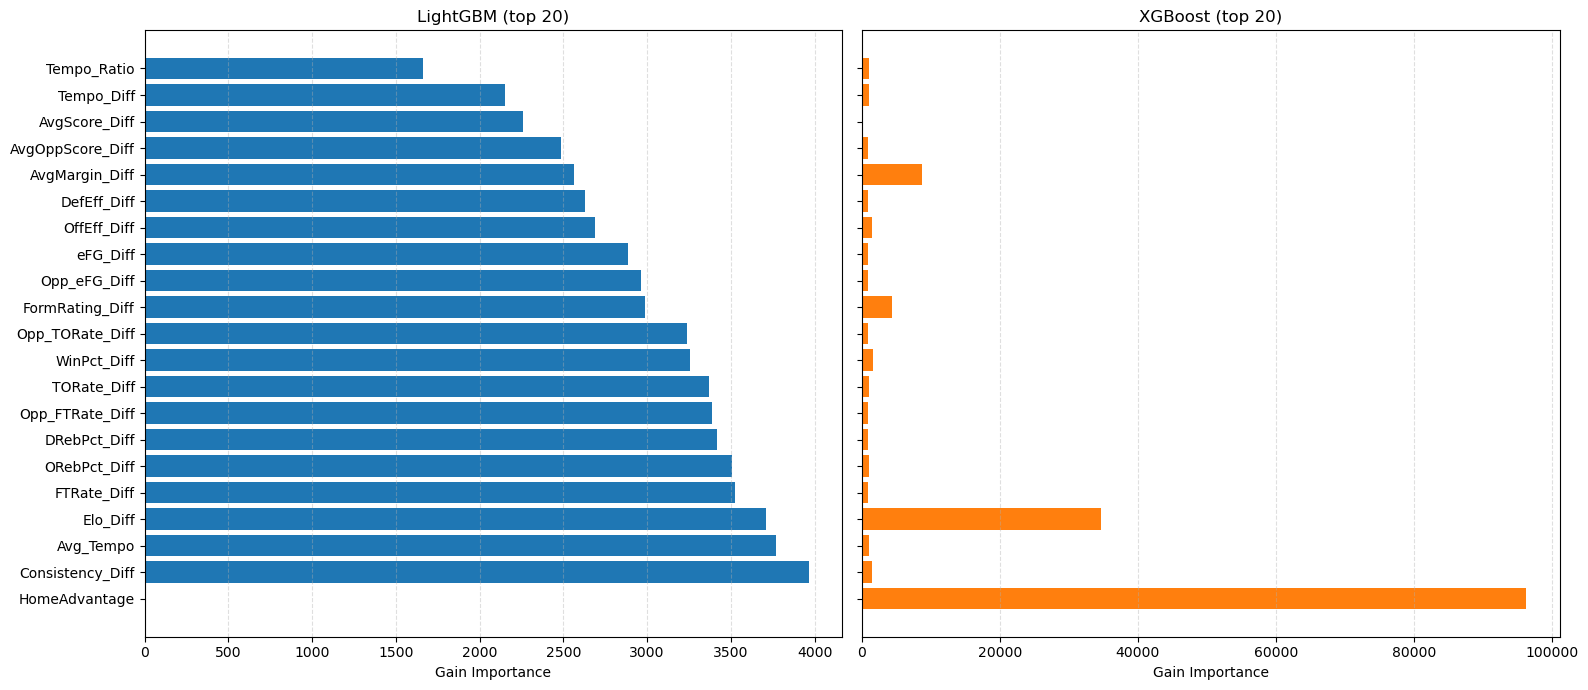

In [27]:
import matplotlib.pyplot as plt

def plot_gbm_feature_importances(lgb_model, xgb_model, feature_names, top_n=20, importance_type="gain"):
    """Plot top-N feature importances for LightGBM and XGBoost side by side."""
    feature_names = list(feature_names)
    top_n = min(top_n, len(feature_names))

    # LightGBM importance (split gain by default)
    lgb_importance = pd.Series(lgb_model.feature_importances_, index=feature_names)
    lgb_top = lgb_importance.sort_values(ascending=False).head(top_n)[::-1]

    # XGBoost importance (map booster feature names back to DataFrame columns)
    booster = xgb_model.get_booster()
    raw_importance = booster.get_score(importance_type=importance_type)
    index_map = {f"f{i}": name for i, name in enumerate(feature_names)}
    mapped_importance = {index_map.get(k, k): v for k, v in raw_importance.items()}
    xgb_importance = pd.Series(mapped_importance).reindex(feature_names).fillna(0.0)
    xgb_top = xgb_importance.sort_values(ascending=False).head(top_n)[::-1]

    fig_height = max(6, top_n * 0.35)
    fig, axes = plt.subplots(1, 2, figsize=(16, fig_height), sharey=True)
    palettes = ['#1f77b4', '#ff7f0e']
    titles = [f"LightGBM (top {len(lgb_top)})", f"XGBoost (top {len(xgb_top)})"]

    for ax, data, color, title in zip(axes, [lgb_top, xgb_top], palettes, titles):
        ax.barh(data.index, data.values, color=color)
        ax.set_title(title)
        ax.set_xlabel('Gain Importance')
        ax.grid(axis='x', linestyle='--', alpha=0.4)

    axes[0].invert_yaxis()  # Highest importance at the top across both plots
    plt.tight_layout()
    plt.show()

plot_gbm_feature_importances(
    lgb_model=lgb_model,
    xgb_model=xgb_model,
    feature_names=gbm_features,
    top_n=20
)

# Make Predictions

In [28]:
from numbers import Number


def _get_latest_team_stats(season, team_id):
    team_games = running_stats_df[
        (running_stats_df['Season'] == season) &
        ((running_stats_df['WTeamID'] == team_id) | (running_stats_df['LTeamID'] == team_id))
    ].sort_values('DayNum')

    if team_games.empty:
        raise ValueError(f"No games found for team {team_id} in season {season}")

    last_game = team_games.iloc[-1]
    if last_game['WTeamID'] == team_id:
        prefix = 'W_'
    else:
        prefix = 'L_'

    stat_names = [
        c[2:] for c in running_stats_df.columns
        if c.startswith('W_') and c not in [
            'WTeamID', 'WScore', 'WLoc', 'WGameNum'
        ]
    ]
    return {stat: last_game[f'{prefix}{stat}'] for stat in stat_names}


def build_detailed_matchup(team1_id, team2_id, season=None):
    """Return a feature-rich comparison table plus engineered metrics for two teams."""
    if season is None:
        season = running_stats_df['Season'].max()

    stats1 = _get_latest_team_stats(season, team1_id)
    stats2 = _get_latest_team_stats(season, team2_id)

    team_lookup = mens_teams.set_index('TeamID')['TeamName']
    team1_name = team_lookup.get(team1_id, f'Team {team1_id}')
    team2_name = team_lookup.get(team2_id, f'Team {team2_id}')

    comparison_rows = []
    for stat in sorted(stats1.keys()):
        val1 = stats1.get(stat, np.nan)
        val2 = stats2.get(stat, np.nan)
        diff = val1 - val2 if isinstance(val1, Number) and isinstance(val2, Number) else np.nan
        comparison_rows.append({
            'Metric': stat,
            team1_name: val1,
            team2_name: val2,
            'Diff (team1 - team2)': diff
        })

    comparison_df = pd.DataFrame(comparison_rows).set_index('Metric')

    net_rating_team1 = stats1['OffEff'] - stats1['DefEff']
    net_rating_team2 = stats2['OffEff'] - stats2['DefEff']
    advanced_features = {
        'HomeAdvantage': 1,
        'Avg_OffEff': np.mean([stats1['OffEff'], stats2['OffEff']]),
        'Avg_DefEff': np.mean([stats1['DefEff'], stats2['DefEff']]),
        'Avg_Tempo': np.mean([stats1['Tempo'], stats2['Tempo']]),
        'NetRating_Team1': net_rating_team1,
        'NetRating_Team2': net_rating_team2,
        'NetRating_Diff': net_rating_team1 - net_rating_team2,
        'Tempo_Ratio': stats1['Tempo'] / (stats2['Tempo'] + 1e-6),
        'OffEff_Diff': stats1['OffEff'] - stats2['OffEff'],
        'DefEff_Diff': stats1['DefEff'] - stats2['DefEff'],
        'Elo_Diff': stats1.get('Elo', np.nan) - stats2.get('Elo', np.nan)
    }

    summary = {
        'season': season,
        'team1_id': team1_id,
        'team2_id': team2_id,
        'team1_name': team1_name,
        'team2_name': team2_name,
        **advanced_features
    }

    return comparison_df.sort_index(), summary

In [29]:
historical_spread_df = None
if os.path.exists("historical_spread_data.csv"):
    historical_spread_df = pd.read_csv("historical_spread_data.csv")


def _lookup_historical_spread(betting_line):
    if betting_line is None or historical_spread_df is None or historical_spread_df.empty:
        return None
    try:
        spread_mag = abs(float(betting_line))
    except (TypeError, ValueError):
        return None
    diffs = (historical_spread_df['Spread'] - spread_mag).abs()
    if diffs.isna().all():
        return None
    return historical_spread_df.loc[diffs.idxmin()]


def predict_matchup(team1_id, team2_id, season=None, betting_line=None):
    if season is None:
        season = running_stats_df['Season'].max()
    stats1 = _get_latest_team_stats(season, team1_id)
    stats2 = _get_latest_team_stats(season, team2_id)
    team_lookup = mens_teams.set_index('TeamID')['TeamName']
    team1_name = team_lookup.get(team1_id, f'Team {team1_id}')
    team2_name = team_lookup.get(team2_id, f'Team {team2_id}')
    feat = {}
    for stat in stats1.keys():
        feat[f'{stat}_Diff'] = stats1[stat] - stats2[stat]
    feat['HomeAdvantage'] = 1  # team1 home
    feat['Avg_Tempo'] = (stats1['Tempo'] + stats2['Tempo']) / 2
    feat['Tempo_Ratio'] = stats1['Tempo'] / (stats2['Tempo'] + 1e-6)
    feat['Elo_Diff'] = stats1.get('Elo', np.nan) - stats2.get('Elo', np.nan)
    wide_vec = np.array([[feat.get(f, 0.0) for f in wide_features]])
    deep_vec = np.array([[feat.get(f, 0.0) for f in deep_features]])
    wide_scaled = wide_scaler.transform(wide_vec)
    deep_scaled = deep_scaler.transform(deep_vec)
    with torch.no_grad():
        pred_margin = model(
            torch.FloatTensor(wide_scaled).to(device),
            torch.FloatTensor(deep_scaled).to(device),
        ).cpu().numpy().flatten()[0]
    win_prob = stats.norm.cdf(pred_margin / 11.0)
    result = {
        'predicted_margin': pred_margin,
        'team1_win_probability': win_prob,
        'team2_win_probability': 1 - win_prob,
        'favorite_team_name': None,
        'favorite_predicted_to_cover': None,
        'favorite_cover_margin': None,
        'historical_spread_used': None,
        'historical_total_games': 0,
        'historical_home_cover_pct': None,
        'historical_away_cover_pct': None,
    }
    if betting_line is not None:
        historical_row = _lookup_historical_spread(betting_line)
        if historical_row is not None:
            result['historical_spread_used'] = float(historical_row['Spread'])
            result['historical_total_games'] = int(historical_row['Total_Games'])
            result['historical_home_cover_pct'] = float(historical_row['Home_Cover_Pct'])
            result['historical_away_cover_pct'] = float(historical_row['Away_Cover_Pct'])
        else:
            result['historical_spread_used'] = betting_line
        favorite_is_team1 = betting_line < 0
        result['favorite_team_name'] = team1_name if favorite_is_team1 else team2_name
        if favorite_is_team1:
            cover_margin = pred_margin + betting_line
        else:
            cover_margin = (-pred_margin) - betting_line
        result['favorite_cover_margin'] = cover_margin
        result['favorite_predicted_to_cover'] = cover_margin > 0
    return result

In [ ]:
matchups = [
    # Enter your matchups based on the team IDs in MTeams.csv and the Vegas lines you want to analyze (if available)
    # Example: (1345 (Purdue), 1322 (Ohio St.), -5.5)  # (home team id, away team id, betting_line)
]

In [34]:
# Build a static HTML page with clickable matchup sections (with predictions)
from html import escape

output_html_path = "matchup_report.html"

html_rows = []
html_rows.append("<!doctype html>")
html_rows.append("<html lang=\"en\">")
html_rows.append("<head>")
html_rows.append("  <meta charset=\"utf-8\" />")
html_rows.append("  <meta name=\"viewport\" content=\"width=device-width, initial-scale=1\" />")
html_rows.append("  <title>Matchup Comparison Report</title>")
html_rows.append("  <style>")
html_rows.append("    :root { --bg: #0f141a; --panel: #182029; --text: #e7eef7; --muted: #9fb0c2; --accent: #59c3ff; }")
html_rows.append("    body { margin: 0; font-family: 'Georgia', serif; background: var(--bg); color: var(--text); }")
html_rows.append("    header { padding: 24px 20px; border-bottom: 1px solid #263241; }")
html_rows.append("    h1 { margin: 0 0 6px 0; font-size: 28px; letter-spacing: 0.4px; }")
html_rows.append("    .sub { color: var(--muted); font-size: 14px; }")
html_rows.append("    main { padding: 18px 20px 40px; max-width: 1200px; margin: 0 auto; }")
html_rows.append("    .matchup { background: var(--panel); border: 1px solid #223042; border-radius: 10px; margin: 12px 0; overflow: hidden; }")
html_rows.append("    summary { cursor: pointer; padding: 14px 16px; list-style: none; font-size: 16px; }")
html_rows.append("    summary::-webkit-details-marker { display: none; }")
html_rows.append("    summary:after { content: '▼'; float: right; color: var(--muted); }")
html_rows.append("    details[open] summary:after { content: '▲'; }")
html_rows.append("    .meta { padding: 0 16px 6px; color: var(--muted); font-size: 13px; }")
html_rows.append("    .pred { padding: 0 16px 14px; color: var(--accent); font-size: 13px; }")
html_rows.append("    .pred ul { margin: 6px 0 0 16px; padding: 0; }")
html_rows.append("    .pred li { margin: 2px 0; }")
html_rows.append("    .table-wrap { padding: 0 16px 18px; overflow-x: auto; }")
html_rows.append("    table { border-collapse: collapse; width: 100%; min-width: 640px; }")
html_rows.append("    th, td { border: 1px solid #2b394b; padding: 6px 8px; text-align: right; font-size: 13px; }")
html_rows.append("    th { background: #1f2a36; color: var(--text); position: sticky; top: 0; }")
html_rows.append("    td:first-child, th:first-child { text-align: left; }")
html_rows.append("    .note { margin-top: 18px; color: var(--muted); font-size: 12px; }")
html_rows.append("  </style>")
html_rows.append("</head>")
html_rows.append("<body>")
html_rows.append("<header>")
html_rows.append("  <h1>Matchup Comparison Report</h1>")
html_rows.append("  <div class=\"sub\">Click a matchup to view the detailed comparison table.</div>")
html_rows.append("</header>")
html_rows.append("<main>")

season_for_report = running_stats_df['Season'].max()

for team1_id, team2_id, line in matchups:
    comparison_df, summary = build_detailed_matchup(team1_id, team2_id, season=season_for_report)
    team1_name = summary['team1_name']
    team2_name = summary['team2_name']
    spread_text = f" | Line: {line:+.1f}" if line is not None else ""
    title = f"{team2_name} @ {team1_name}{spread_text}"
    meta = f"Season {summary['season']} | Team 1: {team1_name} ({team1_id}) | Team 2: {team2_name} ({team2_id})"
    result = predict_matchup(team1_id, team2_id, season=season_for_report, betting_line=line)
    pred_lines = []
    if result['predicted_margin'] > 0:
        pred_lines.append(f"{team1_name} is predicted to win by {result['predicted_margin']:.2f} points")
    else:
        pred_lines.append(f"{team2_name} is predicted to win by {abs(result['predicted_margin']):.2f} points")
    pred_lines.append(f"{team1_name} Win Probability: {result['team1_win_probability']:.4f}")
    pred_lines.append(f"{team2_name} Win Probability: {result['team2_win_probability']:.4f}")
    if line is not None:
        fav_name = result.get('favorite_team_name', 'Favorite') or 'Favorite'
        covers_text = "covers" if result['favorite_predicted_to_cover'] else "does NOT cover"
        cover_margin = result['favorite_cover_margin']
        pred_lines.append(f"Line: {line:+.1f} (team1 perspective)")
        if cover_margin is not None:
            pred_lines.append(f"Favorite ({fav_name}) {covers_text} by {abs(cover_margin):.2f} points against the spread")
        else:
            pred_lines.append(f"Favorite ({fav_name}) {covers_text} the spread")
        historical_spread = result.get("historical_spread_used")
        if historical_spread is not None:
            pred_lines.append("Historical cover odds:")
            pred_lines.append(f"Line used: {historical_spread:+.1f} | Games: {result['historical_total_games']}")
            pred_lines.append(f"Home cover: {result['historical_home_cover_pct']:.1f}%")
            pred_lines.append(f"Away cover: {result['historical_away_cover_pct']:.1f}%")
    pred_html = "<ul>" + "".join([f"<li>{escape(line)}</li>" for line in pred_lines]) + "</ul>"
    table_html = comparison_df.reset_index().to_html(index=False, escape=True)
    html_rows.append("<details class=\"matchup\">")
    html_rows.append(f"  <summary>{escape(title)}</summary>")
    html_rows.append(f"  <div class=\"meta\">{escape(meta)}</div>")
    html_rows.append(f"  <div class=\"pred\">Predictions:{pred_html}</div>")
    html_rows.append("  <div class=\"table-wrap\">")
    html_rows.append(table_html)
    html_rows.append("  </div>")
    html_rows.append("</details>")

html_rows.append("<div class=\"note\">Generated from the notebook matchup list.</div>")
html_rows.append("</main>")
html_rows.append("</body>")
html_rows.append("</html>")

with open(output_html_path, "w", encoding="utf-8") as f:
    f.write("\n".join(html_rows))

print(f"Wrote HTML report to: {output_html_path}")

Wrote HTML report to: matchup_report.html


## Save Model

In [32]:
# Save model and scalers
torch.save({
    'model_state_dict': trained_model.state_dict(),
    'wide_scaler': wide_scaler,
    'deep_scaler': deep_scaler,
    'wide_features': wide_features,
    'deep_features': deep_features,
}, 'regular_season_model_enhanced.pth')

print("Model saved to regular_season_model_enhanced.pth")

Model saved to regular_season_model_enhanced.pth


## Summary

This model predicts regular season game outcomes using:

**No Data Leakage**: Running statistics calculated progressively through the season

**Excludes Games with Zero Stats**: Avoids cold-start issues with zero-initialized stats

**Advanced Metrics**:
- Efficiency and pace (OffEff/DefEff, Tempo)
- Consistency: Standard deviation of recent margins (volatility measure)
- Form Rating: Exponentially weighted recent performance (10-game half-life)

**Elo Rating**: Updated after each game to capture team strength

**Home Court Advantage**: Explicit feature for home/away/neutral games

**Wide & Deep Architecture**: Same proven architecture from March Madness model